In [1]:
import pandas as pd
import numpy as np
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)


In [3]:
df = pd.read_csv("../data/hf_external_validation_data/external_validation_data.csv")
print("="*70)
print("External Validation Dataset Loaded Successfully")
print("="*70)

print("\nShape:")
print(df.shape)

df.head()

External Validation Dataset Loaded Successfully

Shape:
(1552210, 44)


,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,FiO2,pH,PaCO2,SaO2,AST,BUN,Alkalinephos,Calcium,Chloride,Creatinine,Bilirubin_direct,Glucose,Lactate,Magnesium,Phosphate,Potassium,Bilirubin_total,TroponinI,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,NaN,NaN,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,NaN,26.0,0.4,NaN,NaN,NaN,NaN,23.0,NaN,9.6,104.0,0.8,NaN,161.0,NaN,1.6,2.1,3.2,NaN,NaN,29.7,9.5,30.6,11.3,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072


In [4]:
print(df.columns.tolist())
print(df["Patient_ID"].nunique())
print(df["SepsisLabel"].value_counts())
print(df["ICULOS"].max())

['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']
40336
SepsisLabel
0    1524294
1      27916
Name: count, dtype: int64
336


In [5]:
patient_labels = (
    df.groupby("Patient_ID")["SepsisLabel"]
    .max()
)
print(patient_labels.value_counts())
print()
print(patient_labels.value_counts(normalize=True)*100) # normalize converts the categpry into 0 to 1 fraction part and multipyling tht with 100 creates tht as a percentage

SepsisLabel
0    37404
1     2932
Name: count, dtype: int64

SepsisLabel
0    92.731059
1     7.268941
Name: proportion, dtype: float64


In [9]:
## physionet and huuging face dataset comparison
#physio = pd.read_csv("../data/processed/feature_dataset.csv")

#print("PhysioNet Shape :", physio.shape)
#physio.head()
#comparison = pd.DataFrame({
 #   "Metric": [
  #      "Rows",
   #     "Columns"
    #],
   # "PhysioNet": [
    #    len(physio),
     #   physio.shape[1]
    #],
    #"HF Dataset": [
    #    len(df),
   #     df.shape[1]
    #]
#})

#comparison
#common_features = sorted(
 #   list(set(physio.columns) & set(df.columns))
#)

#print(f"Common Features: {len(common_features)}")
#print(common_features)
#physio_missing = physio[common_features].isnull().mean()*100
#hf_missing = df[common_features].isnull().mean()*100

#missing_compare = pd.DataFrame({
 #   "PhysioNet (%)": physio_missing,
  #  "HF Dataset (%)": hf_missing
#})

#missing_compare.sort_values("HF Dataset (%)", ascending=False)
#comparison_stats = []



PhysioNet Shape : (20336, 201)
Common Features: 1
['SepsisLabel']


In [ ]:
print("Shape:", df.shape)
print()
print("Columns:")
for i, col in enumerate(df.columns):   #enumerate loops the list
    print(f"{i+1}. {col}")

In [10]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

print(df.columns.tolist())

['Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']


In [11]:
print("Unique Patients:", df["Patient_ID"].nunique())

print("Total Rows:", len(df))

Unique Patients: 40336
Total Rows: 1552210


In [12]:
patient_hours = (
    df.groupby("Patient_ID")
      .size()
)

patient_hours.describe()

count    40336.000000
mean        38.482001
std         22.795923
min          8.000000
25%         24.000000
50%         38.000000
75%         47.000000
max        336.000000
dtype: float64

In [13]:
patient_labels = (
    df.groupby("Patient_ID")["SepsisLabel"]
      .max()
)

print(patient_labels.value_counts())
print()
print(patient_labels.value_counts(normalize=True)*100)

SepsisLabel
0    37404
1     2932
Name: count, dtype: int64

SepsisLabel
0    92.731059
1     7.268941
Name: proportion, dtype: float64


In [14]:
missing = (
    df.isnull()
      .mean()
      .sort_values(ascending=False)
      *100
)

missing.head(25)

Bilirubin_direct    99.807371
Fibrinogen          99.340167
TroponinI           99.047745
Bilirubin_total     98.509158
Alkalinephos        98.393194
AST                 98.377604
Lactate             97.329872
PTT                 97.055875
SaO2                96.549372
EtCO2               96.286843
Phosphate           95.986303
HCO3                95.810618
Chloride            95.460279
BaseExcess          94.579020
PaCO2               94.440121
Calcium             94.116067
Platelets           94.059502
Creatinine          93.904433
Magnesium           93.689578
WBC                 93.593199
BUN                 93.134434
pH                  93.069688
Hgb                 92.617558
FiO2                91.665754
Hct                 91.145979
dtype: float64

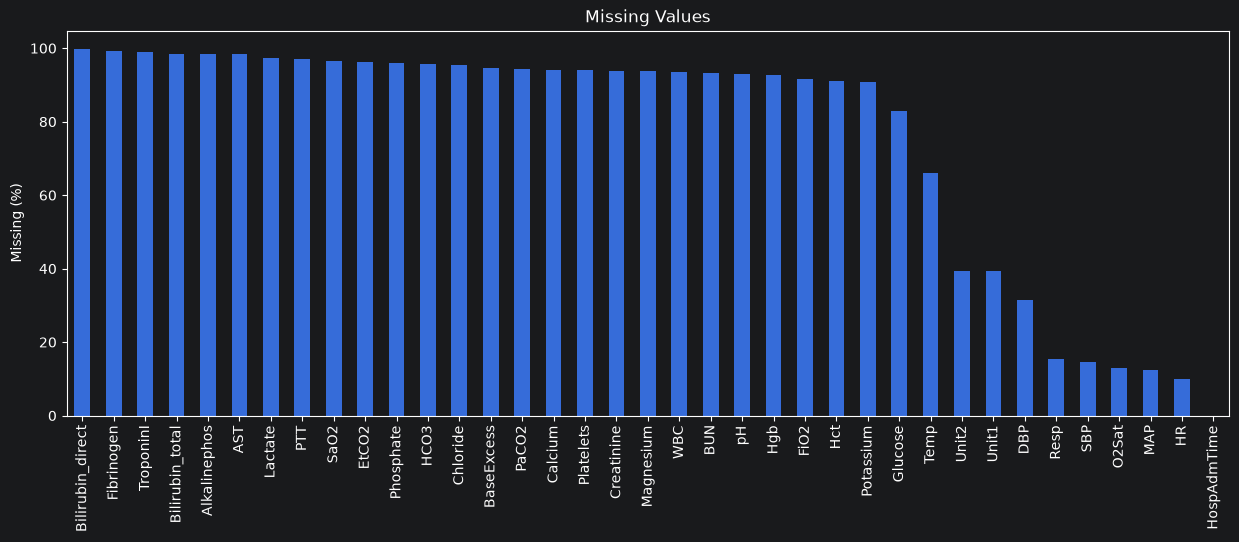

In [15]:
import matplotlib.pyplot as plt

missing[missing>0].plot.bar(figsize=(15,5))

plt.ylabel("Missing (%)")
plt.title("Missing Values")
plt.xticks(rotation=90)
plt.show()

In [16]:
target = df["SepsisLabel"]

features = df.drop(
    columns=[
        "SepsisLabel",
        "Patient_ID"
    ]
)